# Indicator vs Monthly Return Testing

This notebook loads a JSON file containing indicator values and a monthly return variable, then automatically generates scatter plots of each indicator vs the monthly return.

In [117]:
import itertools
import json
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import sklearn
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import cross_val_score
# For ARIMA model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# For ADF test (Augmented Dickey-Fuller)
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
# For ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [118]:
# Suppress warnings to keep your notebook output clean
warnings.filterwarnings("ignore")

# Ensure matplotlib plots render inline in the notebook
%matplotlib inline

In [119]:
import os
print(os.getcwd())


c:\Users\micha\OneDrive\Desktop\TUE\HTT\HTTStockIndustryRankingTool\Notebooks


In [120]:
Path.cwd().parent

WindowsPath('c:/Users/micha/OneDrive/Desktop/TUE/HTT/HTTStockIndustryRankingTool')

In [121]:
path = Path.cwd().parent / "analysis_output" / "clean_dataset.csv"
jdf = pd.read_csv(path)
jdf

,Ticker,Date,BOED,OCF/BOED,ROA,CostExpenses/BOED,Stock/Oil ZScore,PGR,Monthly Return
0,NFG,2025-12-31,53051.0,5182.202032,1.973143,7075.908088,2.825966,11.730000,8.880840
1,COP,2025-12-31,224000.0,88375.000000,6.550816,29205.357143,1.994985,21.739130,16.205524
2,FANG,2025-12-31,497156.0,17616.200951,2.341716,27677.429217,2.364790,53.530000,12.146607
3,DVN,2025-12-31,389000.0,17251.928021,8.361024,7275.064267,1.153904,-0.410000,20.229319
4,EXE,2025-12-31,16164.0,283036.377134,6.430516,597191.289285,2.376671,90.672727,-6.895615
...,...,...,...,...,...,...,...,...,...
765,CKX,1998-12-31,100000.0,4.419620,8.743000,2.191770,-0.371745,0.000000,-4.316563
766,CKX,1998-09-30,21176000.0,0.020871,8.743000,0.010350,-0.371745,829.587357,-4.316563
767,MXC,1998-03-31,104401.0,11.141186,0.976244,29.401519,-0.713093,0.000000,1.960771
768,CKX,1998-03-31,17610000.0,0.025097,8.743000,0.012446,-0.371745,674.070000,-4.316563


In [122]:
path = Path.cwd().parent / "Data" / "oil_industry_data.json"
jdf = pd.read_json(path)
jdf

,XOM,CVX,SHEL,TTE,PBR,PBR.A,BP,EQNR,E,SU,...,CRT,PVL,PRT,USEG,MXC,CKX,EONR,BRN,MTR,TPET
2025-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN
2025-09-30,NaN,"{'BOED': 6609000, 'OCF/BOED': 3502.79921319412...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 1000000, 'OCF/BOED': 0.336296, 'ROA':...",NaN,NaN,NaN,NaN
2025-06-30,NaN,"{'BOED': 3346500, 'OCF/BOED': 4113.25265202450...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 150000, 'OCF/BOED': 0.626840000000000...",NaN,NaN,NaN,NaN
2024-12-31,NaN,"{'BOED': 3338000, 'OCF/BOED': 9434.39185140802...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"{'BOED': 225.33, 'OCF/BOED': 13052.47858696134...","{'BOED': 22061.19, 'OCF/BOED': 9.2815029470305...",NaN,NaN,NaN,NaN
2025-03-31,NaN,"{'BOED': 13412000, 'OCF/BOED': 386.89233522218...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,"{'BOED': 100000, 'OCF/BOED': 1.186640000000000...",NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1996-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1996-06-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1996-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN
1995-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN


In [123]:
s = jdf.stack()
s = s[s.map(type).eq(dict)]

out = pd.json_normalize(s.values)
out.index = s.index

out

out = out.reset_index()
out.columns = ['Date', 'Ticker'] + list(out.columns[2:])
out = out.drop(columns='Date')


out

,Ticker,BOED,OCF/BOED,ROA,CostExpenses/BOED,Stock/Oil ZScore,PGR,Monthly Return
0,NFG,53051.0,5182.202032,1.973143,7075.908088,2.825966,11.730000,8.880840
1,COP,224000.0,88375.000000,6.550816,29205.357143,1.994985,21.739130,16.205524
2,FANG,497156.0,17616.200951,2.341716,27677.429217,2.364790,53.530000,12.146607
3,DVN,389000.0,17251.928021,8.361024,7275.064267,1.153904,-0.410000,20.229319
4,EXE,16164.0,283036.377134,6.430516,597191.289285,2.376671,90.672727,-6.895615
...,...,...,...,...,...,...,...,...
765,CKX,100000.0,4.419620,8.743000,2.191770,-0.371745,0.000000,-4.316563
766,CKX,21176000.0,0.020871,8.743000,0.010350,-0.371745,829.587357,-4.316563
767,MXC,104401.0,11.141186,0.976244,29.401519,-0.713093,0.000000,1.960771
768,CKX,17610000.0,0.025097,8.743000,0.012446,-0.371745,674.070000,-4.316563


In [124]:
# Make sure oil_industry_data.json is in the same level as this notebook
with open(Path.cwd().parent / "Data" / "oil_industry_data.json") as f:
    oil_industry_data =  json.load(f)

In [150]:
oil_industry_data

{'XOM': {'2025-12-31': None,
  '2025-09-30': None,
  '2025-06-30': None,
  '2024-12-31': None,
  '2025-03-31': None,
  '2024-09-30': None,
  '2024-06-30': None,
  '2023-12-31': None,
  '2024-03-31': None,
  '2023-09-30': None,
  '2023-06-30': None,
  '2022-12-31': None,
  '2023-03-31': None,
  '2022-09-30': None,
  '2022-06-30': None,
  '2021-12-31': None,
  '2022-03-31': None,
  '2020-12-31': None,
  '2020-09-30': None,
  '2020-06-30': None,
  '2019-12-31': None,
  '2020-03-31': None,
  '2019-09-30': None,
  '2019-06-30': None},
 'CVX': {'2025-09-30': {'BOED': 6609000,
   'OCF/BOED': 3502.799213194129,
   'ROA': 1.0839170477272657,
   'CostExpenses/BOED': 6704.796489635346,
   'Stock/Oil ZScore': 1.8907107808119483,
   'PGR': 7.22,
   'Monthly Return': -1.2685841273981846},
  '2025-06-30': {'BOED': 3346500,
   'OCF/BOED': 4113.252652024503,
   'ROA': 0.9927438003349015,
   'CostExpenses/BOED': 12154.489765426564,
   'Stock/Oil ZScore': 1.2948218978736037,
   'PGR': 1.66,
   'Monthly R

## EDA

In [126]:
data_rrc = out

In [127]:
X =  out.drop(columns= ["Ticker", "Monthly Return"])
y =  out[["Monthly Return"]]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)


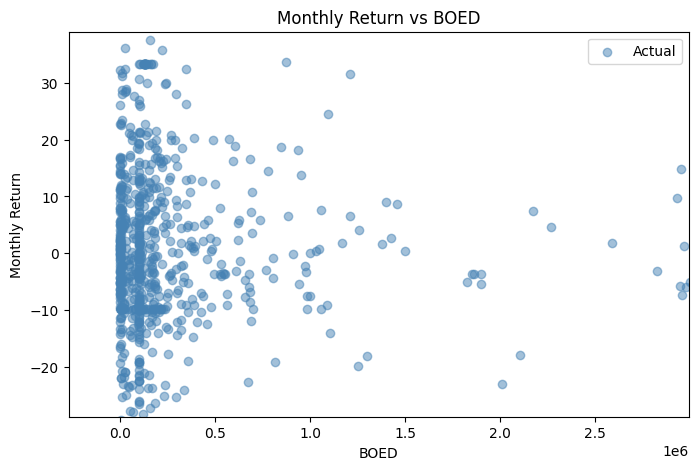

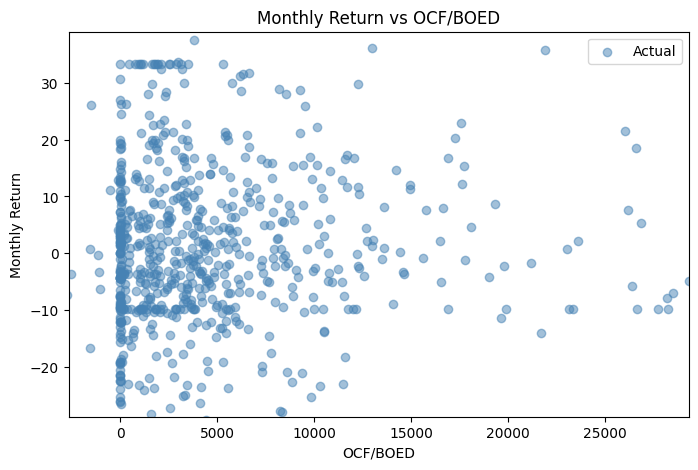

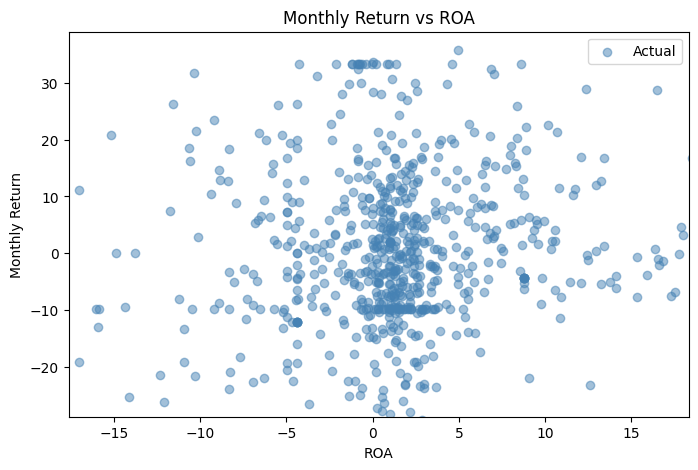

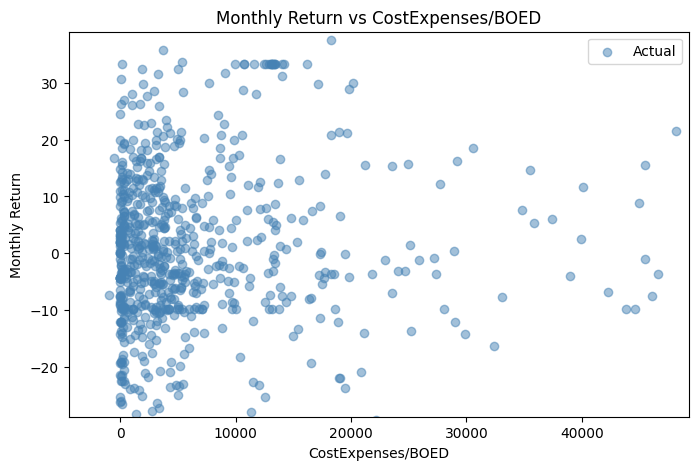

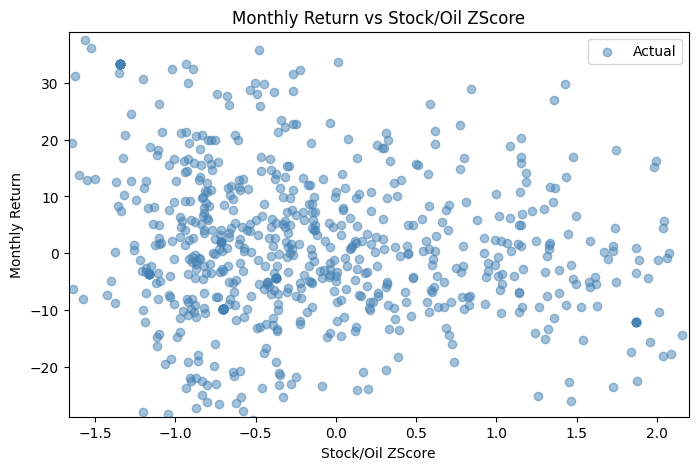

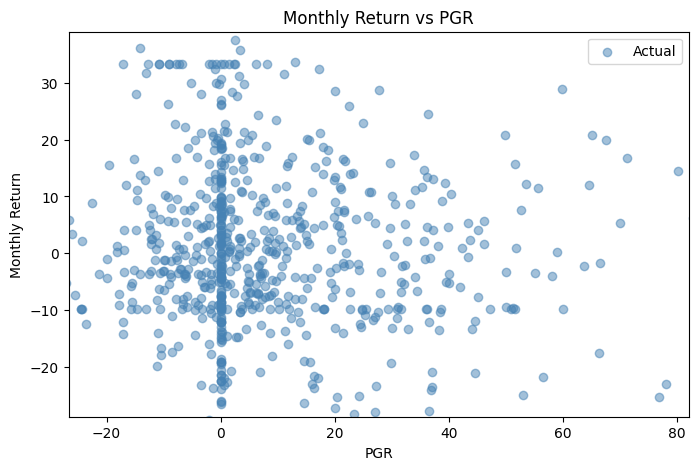

In [128]:
for col in X.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    
    ax.scatter(X[col], y, alpha=0.5, color='steelblue', label='Actual')
    
    # Use percentiles to ignore outliers
    x_low, x_high = X[col].quantile(0.05), X[col].quantile(0.95)
    y_low, y_high = y.quantile(0.05).item(), y.quantile(0.95).item()
    
    x_pad = (x_high - x_low) * 0.1
    y_pad = (y_high - y_low) * 0.1
    
    ax.set_xlim(x_low - x_pad, x_high + x_pad)
    ax.set_ylim(y_low - y_pad, y_high + y_pad)
    
    ax.set_xlabel(col)
    ax.set_ylabel('Monthly Return')
    ax.set_title(f'Monthly Return vs {col}')
    ax.legend()
    plt.show()

## Linear Regression + Random Forest

In [129]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [130]:
model.coef_

array([[-3.47199879e-08,  3.70790841e-05, -2.04894230e-02,
        -3.06141098e-05, -3.70499540e+00, -1.71442256e-03]])

In [131]:
model = RandomForestRegressor(n_estimators=200, random_state=0)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [132]:
preds = model.predict(X_test)

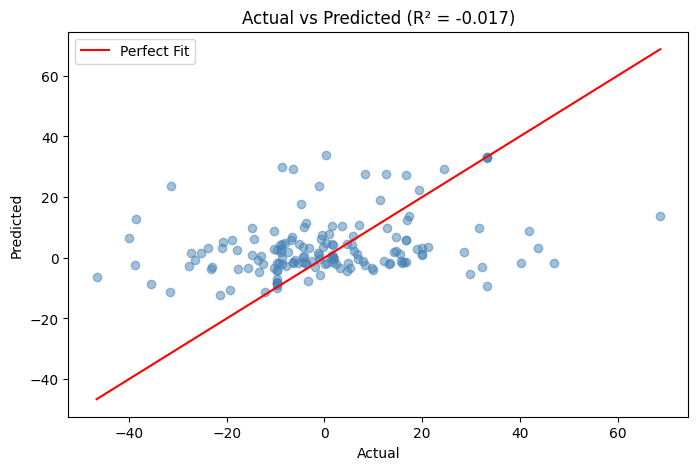

In [133]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Actual vs Predicted (R² = {r2_score(y_test, preds):.3f})')
plt.legend()
plt.show()

## ARIMA Models

Basic Arima (not used)

In [184]:
def train_ARIMA(ticker_data, d_val):
    """
    Trains ARIMA models using all data before 2025 as training,
    selects best order by test MAE on 2025+ data.
    Returns: fitted_model
    """
    target_col = "Monthly Return"
    ts_data = ticker_data[target_col]

    train_mask = ts_data.index < pd.Timestamp('2025-01-01')
    test_mask = ts_data.index >= pd.Timestamp('2025-01-01')
    ts_train = ts_data[train_mask]
    ts_test = ts_data[test_mask]

    best_mae = float('inf')
    best_order = None
    best_model = None

    for order in itertools.product(p, [d_val], q):
        try:
            model = ARIMA(ts_train, order=order)
            results = model.fit()
            if len(ts_test) > 0:
                preds = results.get_forecast(steps=len(ts_test)).predicted_mean
                mae = mean_absolute_error(ts_test, preds)
                if mae < best_mae:
                    best_mae = mae
                    best_order = order
                    best_model = results
        except Exception:
            continue

    print(f"Best order (by test MAE): {best_order}")
    print(f"Best test MAE: {best_mae}")

    # Plot predicted vs actual on test set
    if best_model is not None and len(ts_test) > 0:
        preds = best_model.get_forecast(steps=len(ts_test)).predicted_mean
        plt.figure(figsize=(10, 5))
        plt.plot(ts_test.index, ts_test, label='Actual Returns', marker='o')
        plt.plot(ts_test.index, preds, label='Predicted Returns', marker='x')
        plt.title('Best ARIMA Model: Predicted vs Actual Returns (Test Set)')
        plt.xlabel('Date')
        plt.ylabel('Monthly Return')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return best_model


def ARIMA_Stock_Analysis(forecast_steps, y_aligned, fitted_model):
    print(f"--- Forecasting {forecast_steps/4} Years Ahead ---")

    forecast = fitted_model.get_forecast(steps=forecast_steps)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()

    future_dates = pd.date_range(start=y_aligned.index[-1], periods=forecast_steps + 1, freq='QE')[1:]
    forecast_mean.index = future_dates
    conf_int.index = future_dates

    plt.figure(figsize=(12, 6))
    plt.plot(y_aligned.index, y_aligned, label="Historical Monthly Returns", color="#1f77b4", marker="o")
    plt.plot(forecast_mean.index, forecast_mean, label="ARIMA Forecast", color="#d62728", linestyle="--", marker="x")
    plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                     color="#d62728", alpha=0.15, label="95% Confidence Interval")

    plt.title("Monthly Return - ARIMA Model Forecast", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Monthly Return (%)", fontsize=12)
    plt.axhline(0, color="black", linewidth=1, linestyle="--")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

    y_pred = pd.Series(forecast_mean) / 100
    cum_return_series = (1 + y_pred).cumprod() - 1
    cumulative_return_pct = cum_return_series.iloc[-1] * 100
    return cumulative_return_pct

CVX
Best order (by test MAE): (1, 0, 6)
Best test MAE: 7.463551558045421


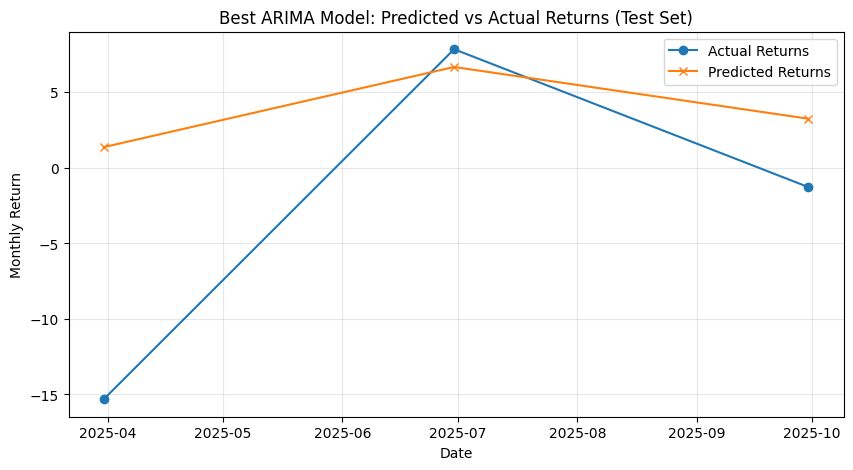

NFG
Best order (by test MAE): (9, 0, 5)
Best test MAE: 5.21101295440563


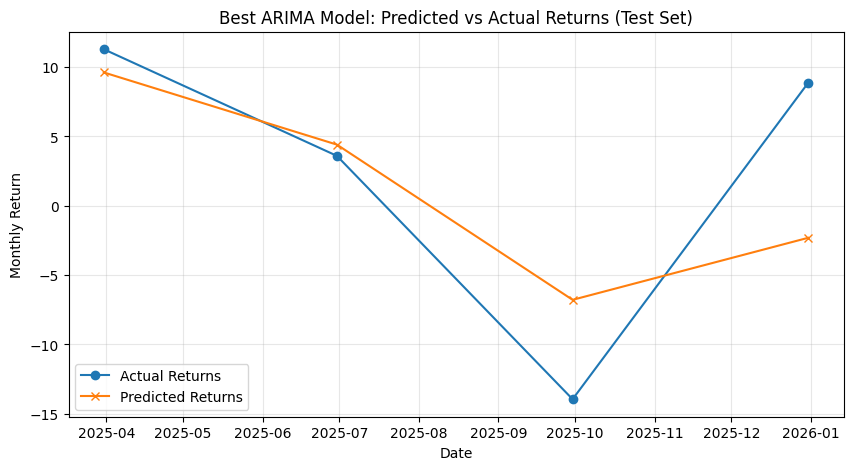

DVN
Best order (by test MAE): (6, 0, 6)
Best test MAE: 7.744209407400918


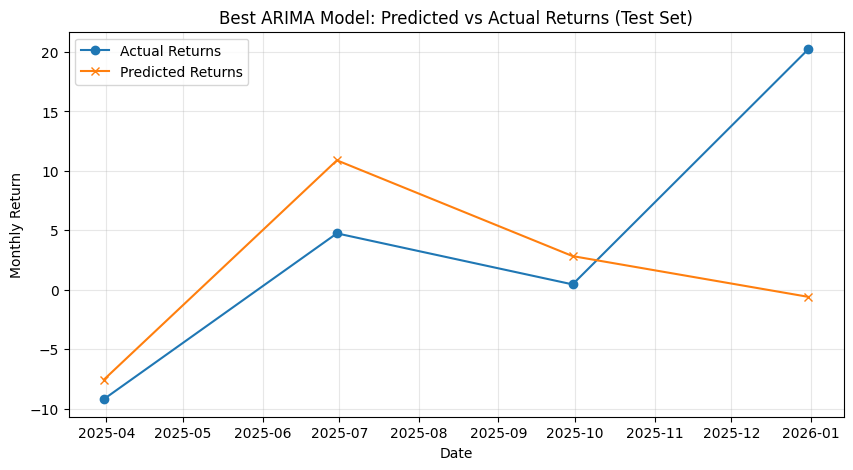

EXE
Best order (by test MAE): (1, 0, 0)
Best test MAE: 9.439108310444231


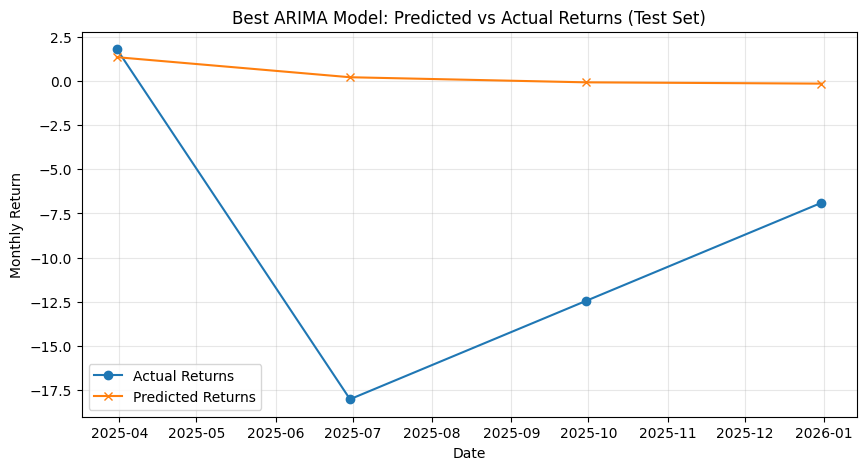

MTDR
Best order (by test MAE): (6, 0, 5)
Best test MAE: 11.400318395612977


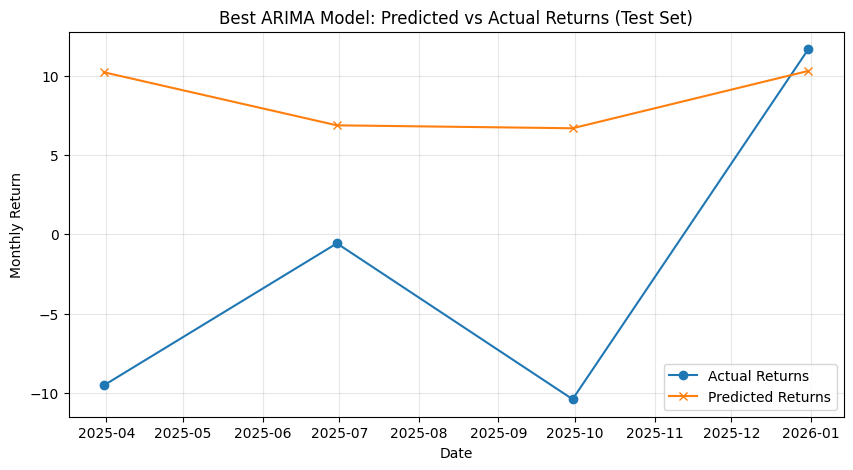

CNX
Best order (by test MAE): (8, 0, 2)
Best test MAE: 8.4858842306681


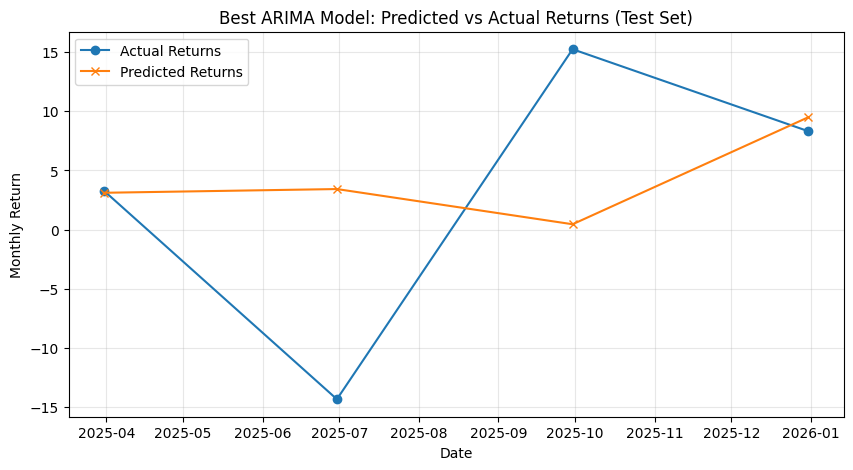

NOG
Best order (by test MAE): None
Best test MAE: inf
RRC
Best order (by test MAE): (9, 1, 4)
Best test MAE: 5.450303859769942


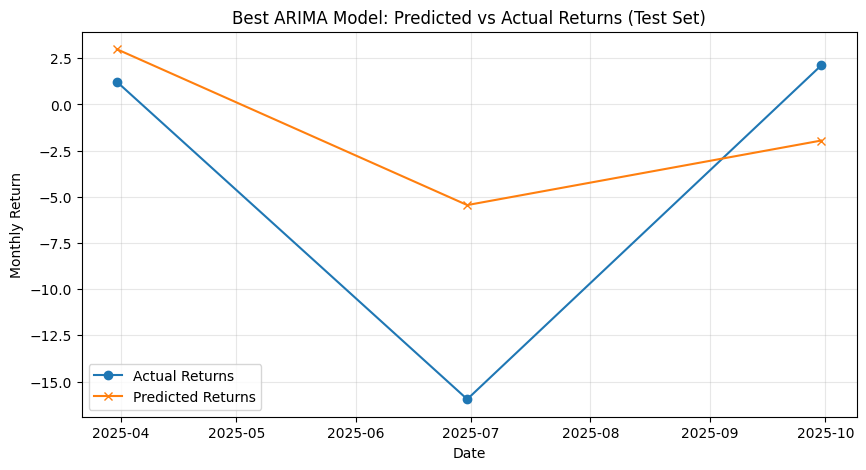

TALO
Best order (by test MAE): (4, 1, 7)
Best test MAE: 6.546005765856119


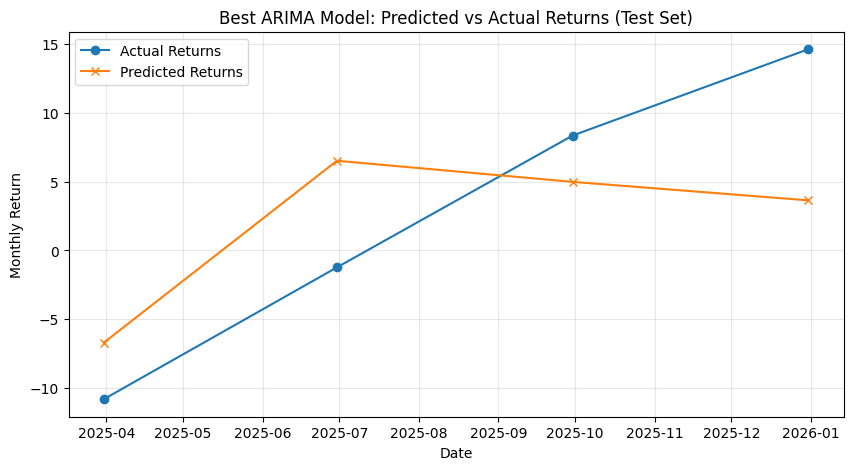

In [187]:
arima_models = {}

for stock_ticker in stationary:
    print(stock_ticker)
    ticker_data = load_data_for_ticker(stock_ticker)
    arima_models[stock_ticker] = train_ARIMA(ticker_data, 0)

for stock_ticker in unit_root:
    print(stock_ticker)
    ticker_data = load_data_for_ticker(stock_ticker)
    arima_models[stock_ticker] = train_ARIMA(ticker_data, 1)

Filtering Data to Determine which stock datasets are viable for training

In [166]:
def load_data_for_ticker(ticker):
    try:
        oil_stock_data = oil_industry_data.get(ticker, {})
        df = pd.DataFrame.from_dict(oil_stock_data, orient='index')
        df.index = pd.to_datetime(df.index)
        df = df.sort_index().resample('QE').mean()  # <-- changed
        df = df.dropna(axis=1, how='all')
        df = df.interpolate(method='linear', limit_direction='both')
        return df
    except Exception as e:
        print(f"Error loading {ticker}: {e}")
        return None

In [167]:
def enough_data_points(ticker_data):
    if ticker_data is None:
        return False
    else:
        if len(ticker_data) < 20:
            return False
        else:
            return True

In [168]:
def check_stationary_category(column_data):
    adf_result = adfuller(column_data)
    kpss_result = kpss(column_data)

    if (adf_result[1] < 0.05 and kpss_result[1] > 0.05):
        # Stationary
        return "stationary"
    elif (adf_result[1] > 0.05 and kpss_result[1] < 0.05):
        # Unit-Root
        return "unit-root"
    else:
        # Neither
        return "other"

In [169]:
def check_arima_category(ticker_data):
    columns = ["OCF/BOED", "ROA", "CostExpenses/BOED", "Stock/Oil ZScore", "PGR"]

    arima_category = {'stationary': 0, 'unit_root': 0, 'other': 0}
    for indicator in columns:
        arima_type = check_stationary_category(ticker_data[indicator])
        if arima_type == "stationary":
            arima_category['stationary'] += 1
        elif arima_type == "unit-root": 
            arima_category['unit_root'] += 1
        else:
            arima_category['other'] +=1

    return max(arima_category, key=arima_category.get)

In [170]:
unviable = []
unit_root = []
stationary = []
other = []

for stock_ticker in oil_industry_data.keys():
    ticker_data = load_data_for_ticker(stock_ticker)
    
    if not enough_data_points(ticker_data):
        print(f"{stock_ticker} -> unviable (not enough data, len={len(ticker_data) if ticker_data is not None else 'None'})")
        unviable.append(stock_ticker)
    else:
        if len(ticker_data.columns) == 0:
            print(f"{stock_ticker} -> unviable (no columns)")
            unviable.append(stock_ticker)
            continue

        monthly_return_category = check_stationary_category(ticker_data["Monthly Return"])
        print(f"{stock_ticker} -> Monthly Return category: {monthly_return_category}")
        
        if monthly_return_category == "stationary":
            arima_category = check_arima_category(ticker_data)
            print(f"{stock_ticker} -> ARIMA category: {arima_category}")
            
            if arima_category == "stationary":
                stationary.append(stock_ticker)
            elif arima_category == "unit_root":
                unit_root.append(stock_ticker)
            else:
                other.append(stock_ticker)
        else:
            print(f"{stock_ticker} -> unviable (Monthly Return not stationary)")
            unviable.append(stock_ticker)

print(f"\nstationary: {stationary}")
print(f"unit_root: {unit_root}")
print(f"unviable: {unviable}")

XOM -> unviable (no columns)
CVX -> Monthly Return category: stationary
CVX -> ARIMA category: stationary
Error loading SHEL: object of type 'NoneType' has no len()
SHEL -> unviable (not enough data, len=None)
Error loading TTE: object of type 'NoneType' has no len()
TTE -> unviable (not enough data, len=None)
Error loading PBR: object of type 'NoneType' has no len()
PBR -> unviable (not enough data, len=None)
Error loading PBR.A: object of type 'NoneType' has no len()
PBR.A -> unviable (not enough data, len=None)
Error loading BP: object of type 'NoneType' has no len()
BP -> unviable (not enough data, len=None)
Error loading EQNR: object of type 'NoneType' has no len()
EQNR -> unviable (not enough data, len=None)
Error loading E: object of type 'NoneType' has no len()
E -> unviable (not enough data, len=None)
Error loading SU: object of type 'NoneType' has no len()
SU -> unviable (not enough data, len=None)
Error loading IMO: object of type 'NoneType' has no len()
IMO -> unviable (not

In [171]:
stationary

['CVX', 'NFG', 'DVN', 'EXE', 'MTDR', 'CNX', 'NOG']

In [172]:
unit_root

['RRC', 'TALO']

CVX
Best order (by test MAE): (2, 0, 8)
Best test MAE: 1.8899909653368987


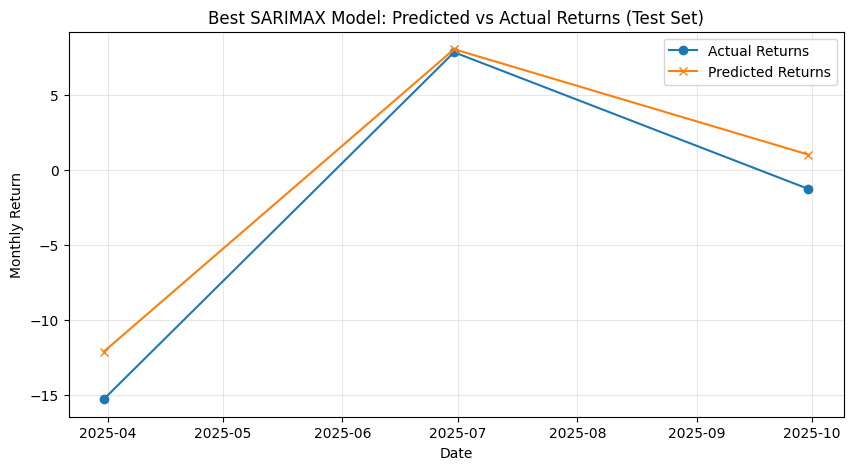

NFG
Best order (by test MAE): (2, 0, 7)
Best test MAE: 8.749326155961853


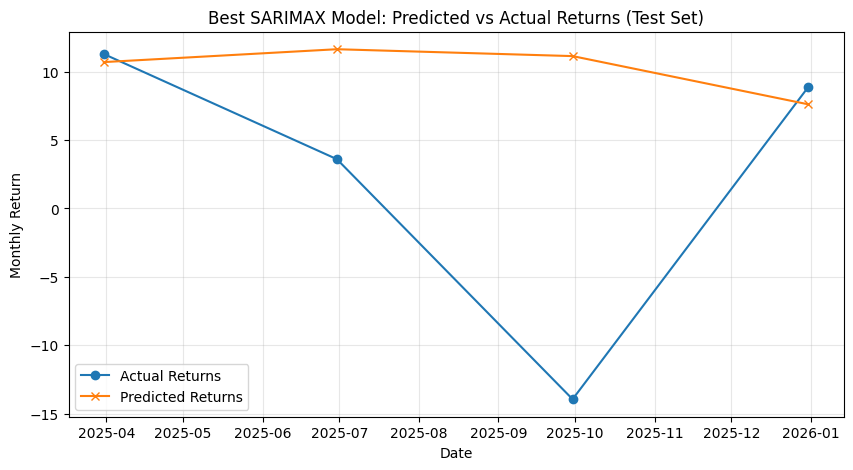

DVN
Best order (by test MAE): (9, 0, 7)
Best test MAE: 6.941966196413546


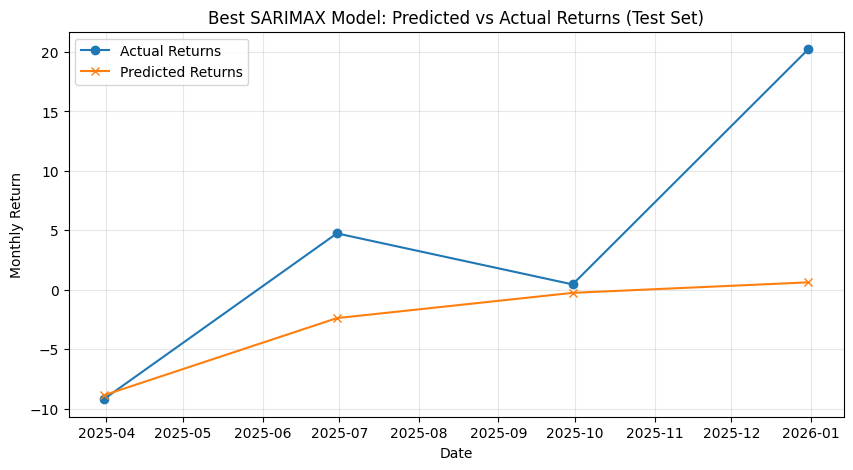

EXE
Best order (by test MAE): (9, 0, 7)
Best test MAE: 15.356338332427413


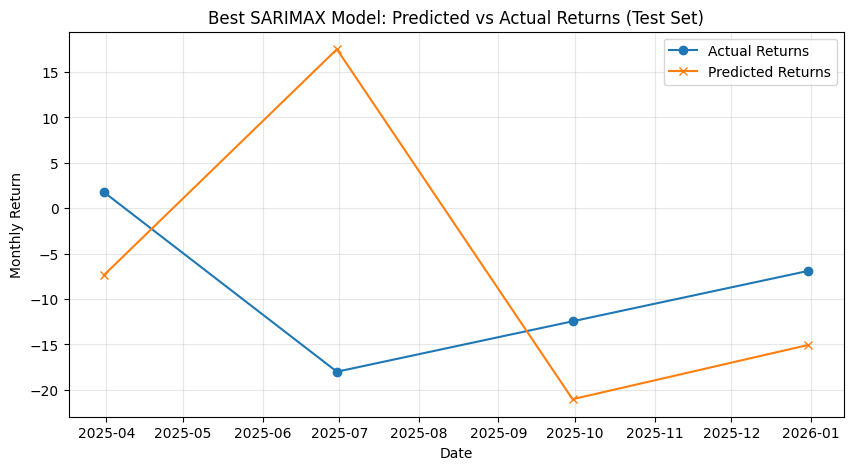

MTDR
Best order (by test MAE): (1, 0, 0)
Best test MAE: 6.481738229847897


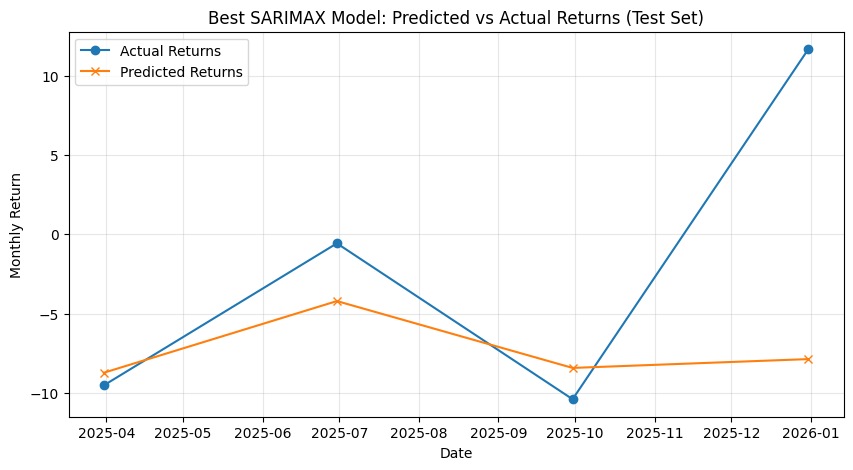

CNX
Best order (by test MAE): (7, 0, 4)
Best test MAE: 12.831819361856052


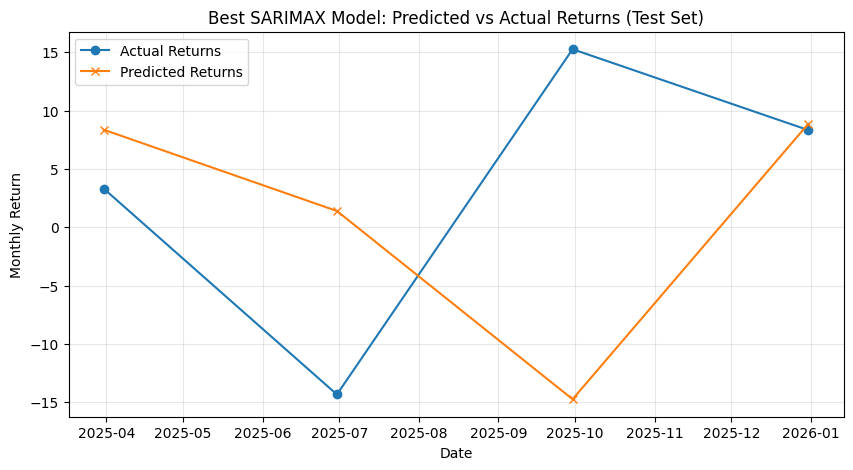

NOG
Best order (by test MAE): None
Best test MAE: inf
RRC
Best order (by test MAE): (0, 1, 1)
Best test MAE: 22.313362168800946


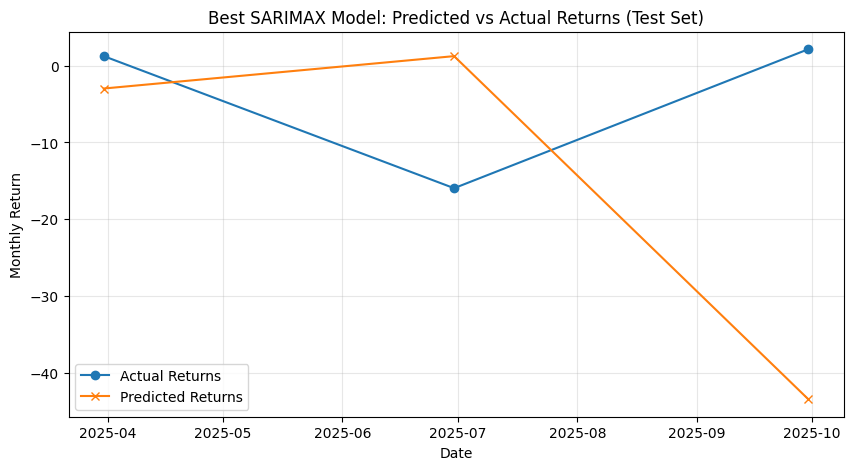

TALO
Best order (by test MAE): (5, 1, 0)
Best test MAE: 2.9884707115462255


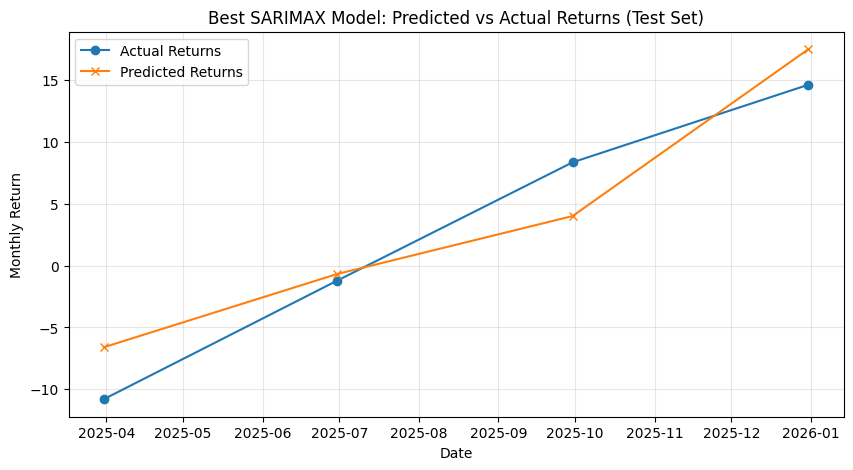

In [189]:
y_aligned_vals = {}
sarimax_models = {}
last_financials_vals = {}

for stock_ticker in stationary: 
    print(stock_ticker)
    ticker_data = load_data_for_ticker(stock_ticker)
    last_known, y_aligned, sarimax_model = train_SARIMAX(ticker_data, 0)
    y_aligned_vals[stock_ticker] = y_aligned
    sarimax_models[stock_ticker] = sarimax_model
    last_financials_vals[stock_ticker] = last_known

for stock_ticker in unit_root:
    print(stock_ticker)
    ticker_data = load_data_for_ticker(stock_ticker)
    last_known, y_aligned, sarimax_model = train_SARIMAX(ticker_data, 1)
    y_aligned_vals[stock_ticker] = y_aligned
    sarimax_models[stock_ticker] = sarimax_model
    last_financials_vals[stock_ticker] = last_known

SARIMAX Model Training

In [173]:
p = range(0, 10)
q = range(0, 10)

In [174]:
def train_SARIMAX(ticker_data, d_val):
    """
    Trains SARIMAX models using all data before 2025 as training data, and selects the model with the best prediction accuracy
    (lowest MAE) on the data from 2025 onwards (inclusive), using exogenous variables.
    Visualizes the best model's predictions vs actual returns before returning.
    Returns: last_known_financials, y_aligned, best_model
    """
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_absolute_error
    target_col = "Monthly Return"
    y = ticker_data[target_col]
    X = ticker_data.drop(columns=[target_col, "BOED"]) if "BOED" in ticker_data.columns else ticker_data.drop(columns=[target_col])
    X_lagged = X.shift(1)
    aligned_df = pd.concat([y, X_lagged], axis=1).dropna()
    y_aligned = aligned_df[target_col]
    X_lagged_aligned = aligned_df.drop(columns=[target_col])

    # Define training data as all data before 2025, test as 2025 and after (inclusive)
    train_mask = y_aligned.index < pd.Timestamp('2025-01-01')
    test_mask = y_aligned.index >= pd.Timestamp('2025-01-01')
    y_train = y_aligned[train_mask]
    X_train = X_lagged_aligned[train_mask]
    y_test = y_aligned[test_mask]
    X_test = X_lagged_aligned[test_mask]

    best_mae = np.inf
    best_order = None
    best_model = None
    best_preds = None

    for order in itertools.product(p, [d_val], q):
        try:
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            results = model.fit(disp=False)
            # Predict on test set
            if len(y_test) > 0:
                preds = results.get_forecast(steps=len(y_test), exog=X_test).predicted_mean
                mae = mean_absolute_error(y_test, preds)
            else:
                preds = None
                mae = np.inf
            if mae < best_mae:
                best_mae = mae
                best_order = order
                best_model = results
                best_preds = preds
        except Exception as e:
            continue

    print("Best order (by test MAE):", best_order)
    print("Best test MAE:", best_mae)
    last_known_financials = X_lagged_aligned.iloc[-1:]

    # Visualization: Best model's predictions vs actual returns
    if best_preds is not None and len(y_test) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(y_test.index, y_test, label='Actual Returns', marker='o')
        plt.plot(y_test.index, best_preds, label='Predicted Returns', marker='x')
        plt.title('Best SARIMAX Model: Predicted vs Actual Returns (Test Set)')
        plt.xlabel('Date')
        plt.ylabel('Monthly Return')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return last_known_financials, y_aligned, best_model


In [179]:
def SARIMAX_Stock_Analysis(forecast_steps, last_known_financials, y_aligned, fitted_model):
    print(f"--- Forecasting {forecast_steps/4} Years Ahead ---")
    # To forecast the future, SARIMAX needs future Exogenous variables.
    # We will assume that the stock's financials remain exactly the same as the most recent quarter.
    future_X = pd.concat([last_known_financials] * forecast_steps, ignore_index=True)

    # Generate the forecast
    forecast = fitted_model.get_forecast(steps=forecast_steps, exog=future_X)
    forecast_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()

    # Create future dates for plotting
    future_dates = pd.date_range(start=y_aligned.index[-1], periods=forecast_steps + 1, freq='QE')[1:]
    forecast_mean.index = future_dates
    conf_int.index = future_dates

    # ==========================================
    # Visualization
    # ==========================================
    plt.figure(figsize=(12, 6))

    historical_label = f"Historical Monthly Returns"

    # Plot Historical
    plt.plot(y_aligned.index, y_aligned, label=historical_label, color="#1f77b4", marker="o")

    # Plot Forecast
    plt.plot(forecast_mean.index, forecast_mean, label="SARIMAX Forecast (Using Financial Metrics)", color="#ff7f0e", linestyle="--", marker="x")

    # Shade Confidence Interval
    plt.fill_between(conf_int.index, 
                    conf_int.iloc[:, 0], 
                    conf_int.iloc[:, 1], 
                    color="#ff7f0e", alpha=1, label="95% Confidence Interval")

    plt.title("Monthly Return - SARIMAX Model (Financial Metrics Included)", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Monthly Return (%)", fontsize=12)
    plt.axhline(0, color="black", linewidth=1, linestyle="--")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.show()

    # forecast_mean: pd.Series or list of predicted returns (whole-number percentages) for the forecast horizon
    # Returns the total cumulative return over the forecast horizon as a single percentage
    # Convert to decimal
    y_pred = pd.Series(forecast_mean) / 100  
    # Compute cumulative growth over forecast horizon
    cum_return_series = (1 + y_pred).cumprod() - 1  
    # Take the final value → cumulative return for forecast period only
    cumulative_return_pct = cum_return_series.iloc[-1] * 100  
    return cumulative_return_pct

In [176]:
def train_SARIMAX_aic(ticker_data, d_val):
    """
    Trains SARIMAX models using all data before 2025 as training data, and selects the model with the best AIC
    (lowest AIC) on the training set, using exogenous variables.
    Visualizes the best model's predictions vs actual returns on the test set (2025 and after) before returning.
    Returns: last_known_financials, y_aligned, best_model
    """
    import matplotlib.pyplot as plt
    target_col = "Monthly Return"
    y = ticker_data[target_col]
    X = ticker_data.drop(columns=[target_col, "BOED"]) if "BOED" in ticker_data.columns else ticker_data.drop(columns=[target_col])
    X_lagged = X.shift(1)
    aligned_df = pd.concat([y, X_lagged], axis=1).dropna()
    y_aligned = aligned_df[target_col]
    X_lagged_aligned = aligned_df.drop(columns=[target_col])

    # Define training data as all data before 2025, test as 2025 and after (inclusive)
    train_mask = y_aligned.index < pd.Timestamp('2025-01-01')
    test_mask = y_aligned.index >= pd.Timestamp('2025-01-01')
    y_train = y_aligned[train_mask]
    X_train = X_lagged_aligned[train_mask]
    y_test = y_aligned[test_mask]
    X_test = X_lagged_aligned[test_mask]

    best_aic = float('inf')
    best_order = None
    best_model = None
    best_preds = None

    for order in itertools.product(p, [d_val], q):
        try:
            model = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            results = model.fit(disp=False)
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_model = results
        except Exception as e:
            continue

    print("Best order (by train AIC):", best_order)
    print("Best train AIC:", best_aic)
    last_known_financials = X_lagged_aligned.iloc[-1:]

    # Visualization: Best model's predictions vs actual returns (on test set)
    if best_model is not None and len(y_test) > 0:
        preds = best_model.get_forecast(steps=len(y_test), exog=X_test).predicted_mean
        plt.figure(figsize=(10, 5))
        plt.plot(y_test.index, y_test, label='Actual Returns', marker='o')
        plt.plot(y_test.index, preds, label='Predicted Returns', marker='x')
        plt.title('Best SARIMAX Model (AIC): Predicted vs Actual Returns (Test Set)')
        plt.xlabel('Date')
        plt.ylabel('Monthly Return')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return last_known_financials, y_aligned, best_model


Train Models and use them to Forecast Returns

CVX
Best order (by test MAE): (2, 0, 8)
Best test MAE: 1.8899909653368987


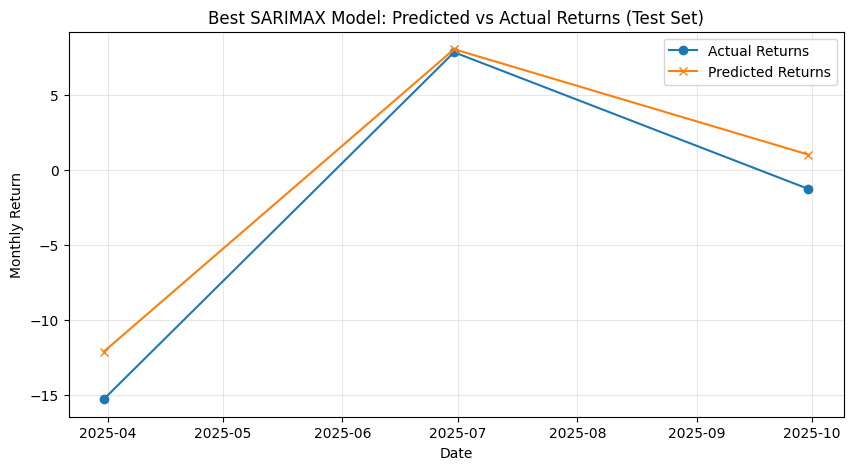

NFG
Best order (by test MAE): (2, 0, 7)
Best test MAE: 8.749326155961853


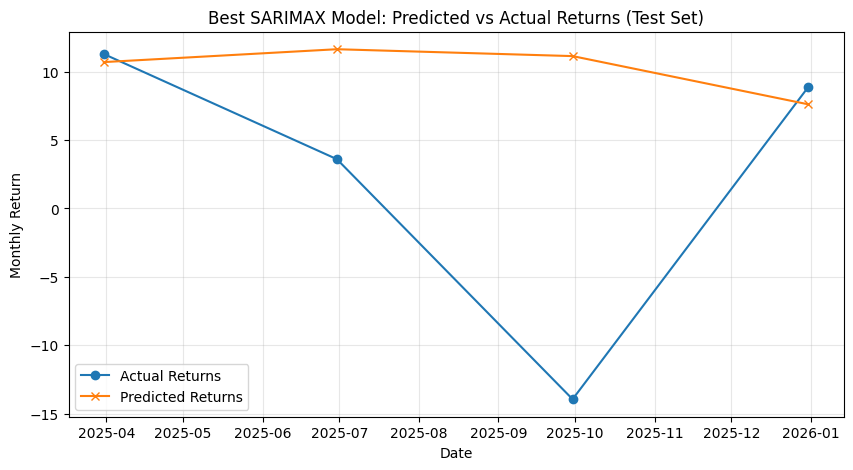

DVN
Best order (by test MAE): (9, 0, 7)
Best test MAE: 6.941966196413546


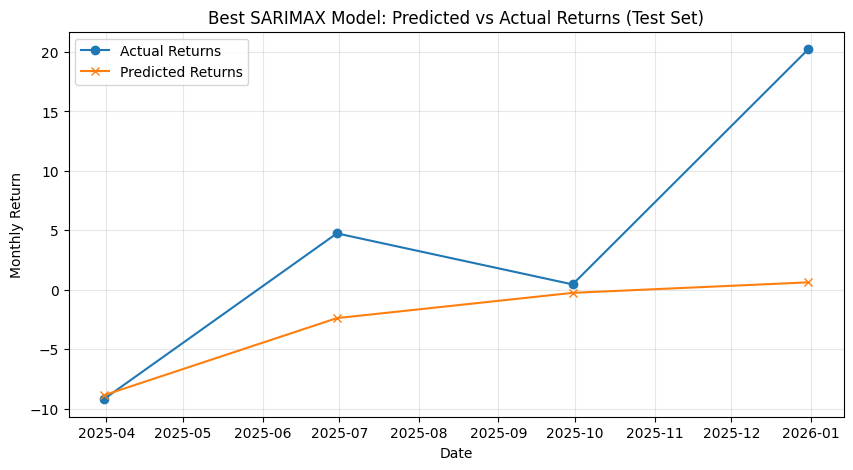

EXE
Best order (by test MAE): (9, 0, 7)
Best test MAE: 15.356338332427413


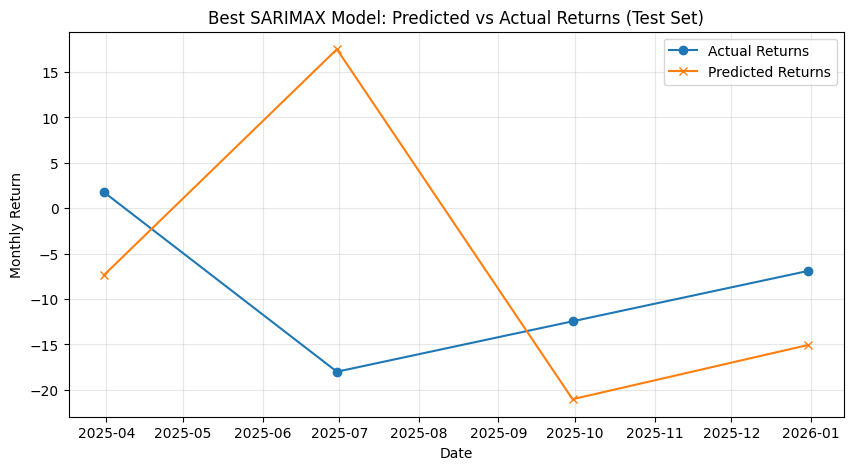

MTDR
Best order (by test MAE): (1, 0, 0)
Best test MAE: 6.481738229847897


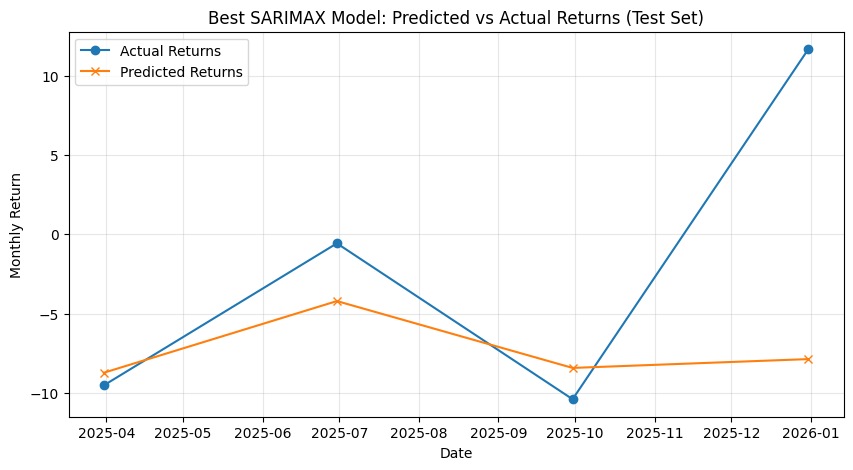

CNX
Best order (by test MAE): (7, 0, 4)
Best test MAE: 12.831819361856052


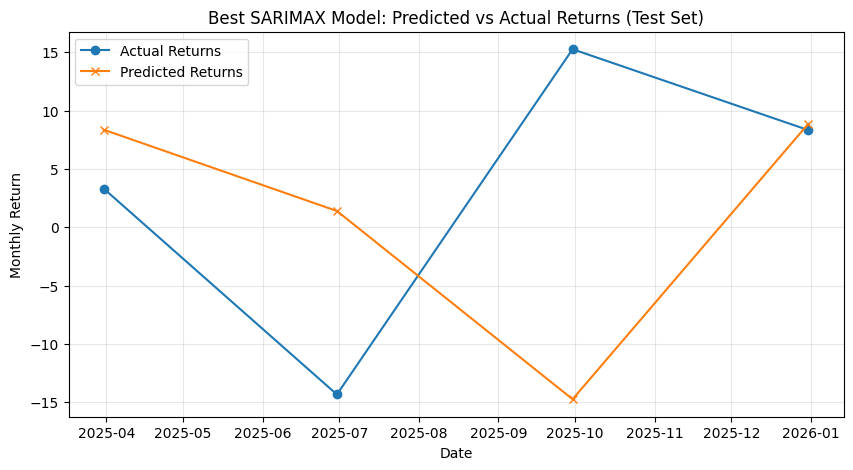

NOG
Best order (by test MAE): None
Best test MAE: inf
RRC
Best order (by test MAE): (0, 1, 1)
Best test MAE: 22.313362168800946


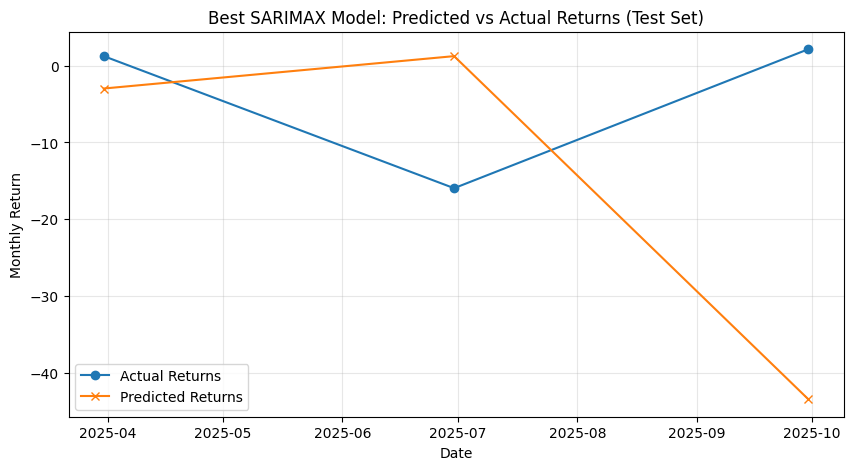

TALO
Best order (by test MAE): (5, 1, 0)
Best test MAE: 2.9884707115462255


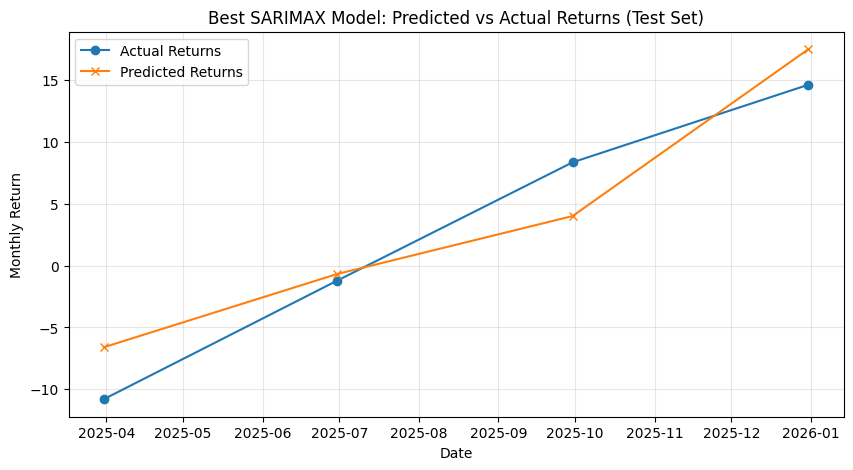

In [177]:
y_aligned_vals = {}
sarimax_models = {}
last_financials_vals = {}

for stock_ticker in stationary: 
    print(stock_ticker)
    ticker_data = load_data_for_ticker(stock_ticker)
    last_known, y_aligned, sarimax_model = train_SARIMAX(ticker_data, 0)
    y_aligned_vals[stock_ticker] = y_aligned
    sarimax_models[stock_ticker] = sarimax_model
    last_financials_vals[stock_ticker] = last_known

for stock_ticker in unit_root:
    print(stock_ticker)
    ticker_data = load_data_for_ticker(stock_ticker)
    last_known, y_aligned, sarimax_model = train_SARIMAX(ticker_data, 1)
    y_aligned_vals[stock_ticker] = y_aligned
    sarimax_models[stock_ticker] = sarimax_model
    last_financials_vals[stock_ticker] = last_known

CVX
--- Forecasting 0.25 Years Ahead ---


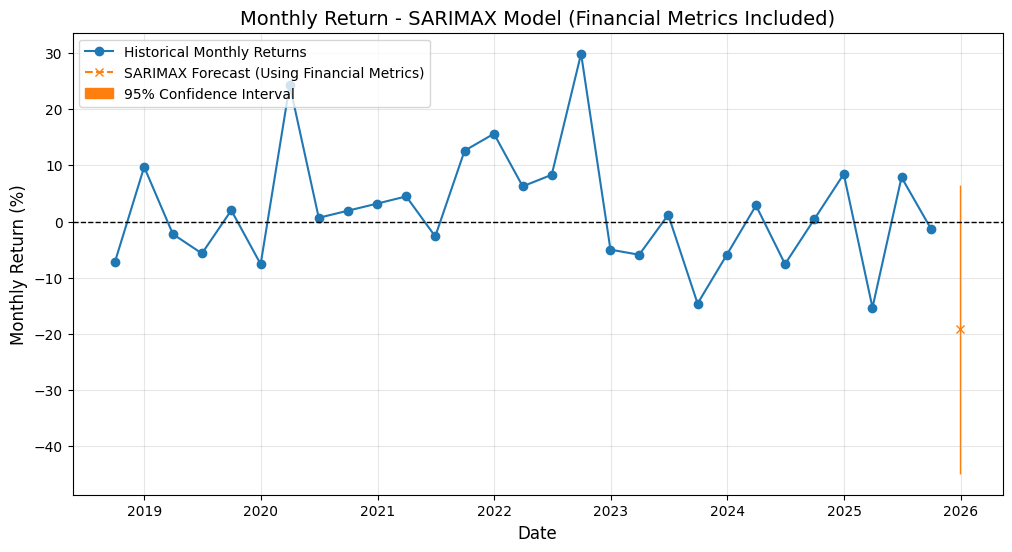

NFG
--- Forecasting 0.25 Years Ahead ---


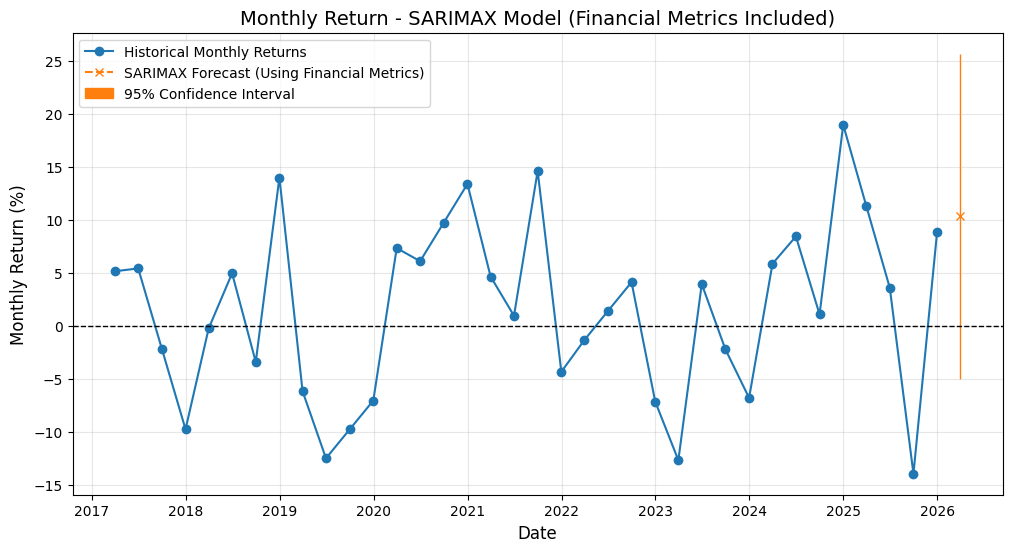

DVN
--- Forecasting 0.25 Years Ahead ---


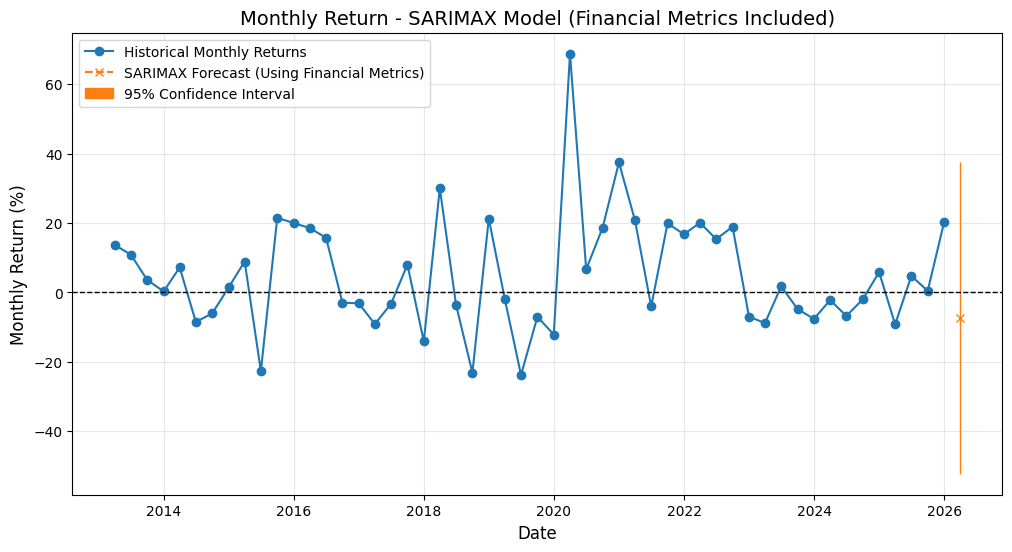

EXE
--- Forecasting 0.25 Years Ahead ---


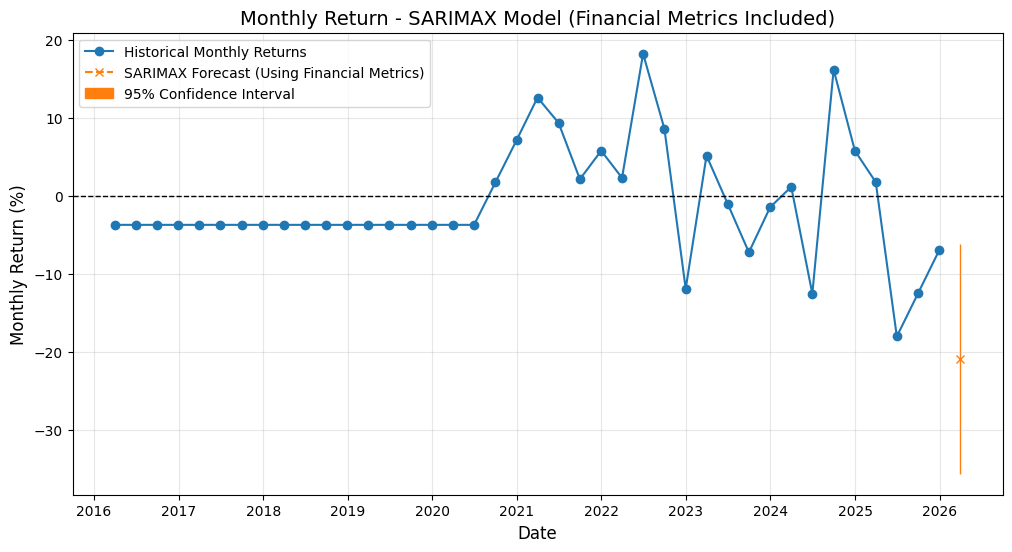

MTDR
--- Forecasting 0.25 Years Ahead ---


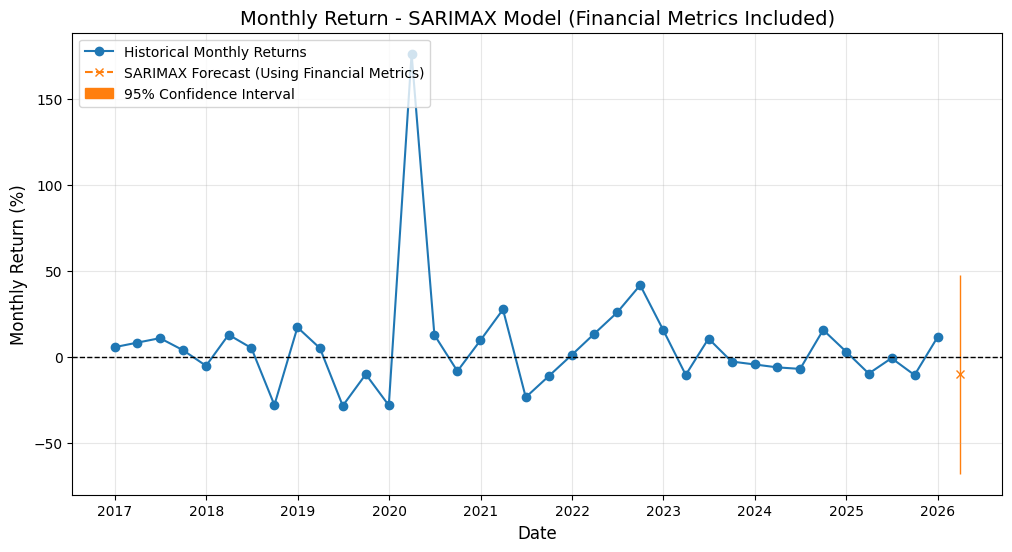

CNX
--- Forecasting 0.25 Years Ahead ---


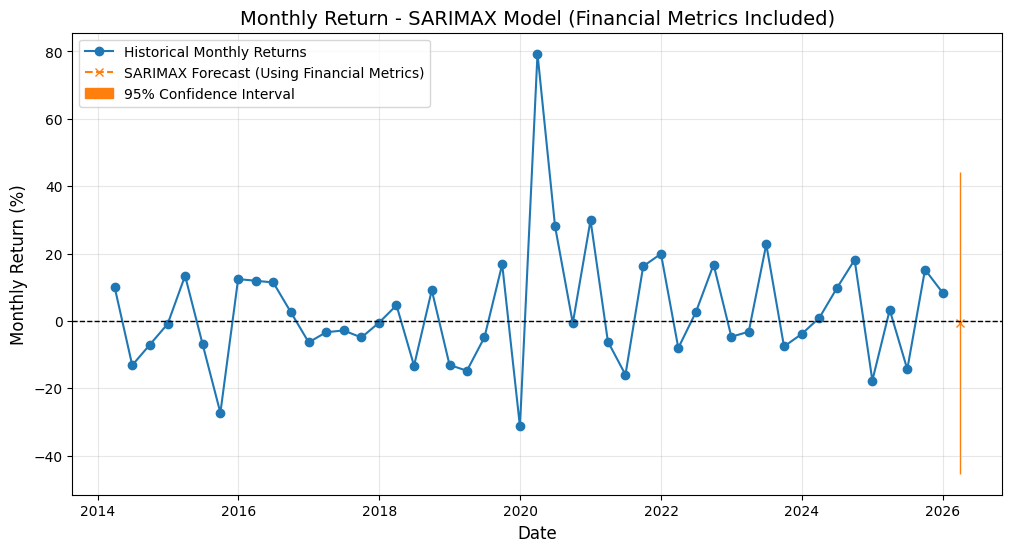

NOG
--- Forecasting 0.25 Years Ahead ---
'NoneType' object has no attribute 'get_forecast'
RRC
--- Forecasting 0.25 Years Ahead ---


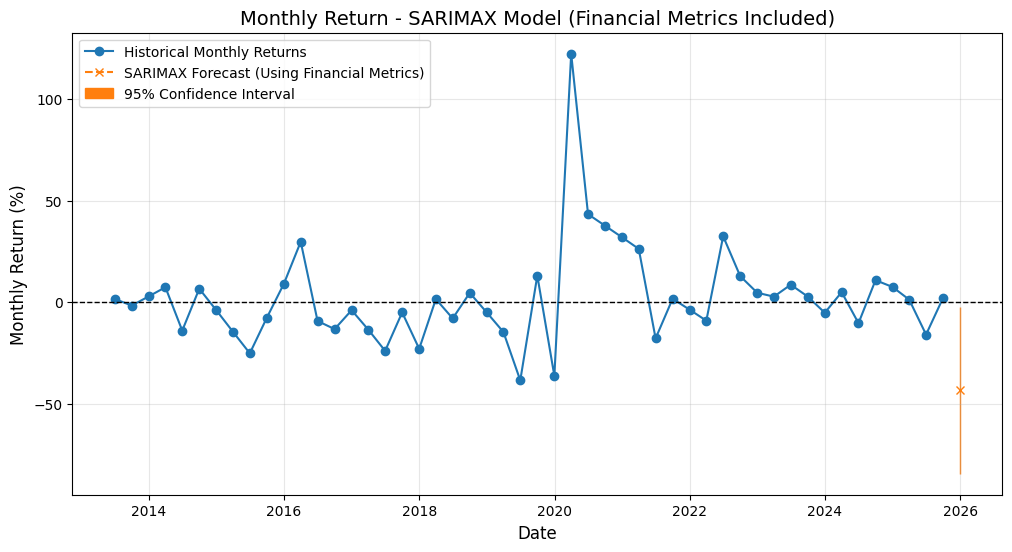

TALO
--- Forecasting 0.25 Years Ahead ---


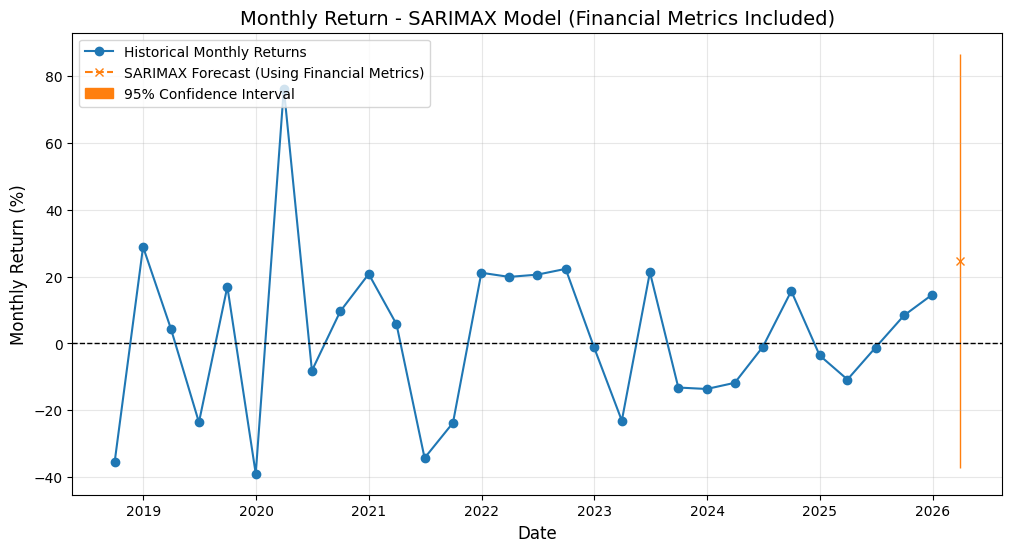

In [180]:
cumulative_returns = {}
all_stocks = stationary + unit_root

for stock_ticker in all_stocks:
    try:
        print(stock_ticker)
        y_aligned = y_aligned_vals[stock_ticker] 
        sarimax_model = sarimax_models[stock_ticker]
        last_known = last_financials_vals[stock_ticker]
        cumulative_returns[stock_ticker] = SARIMAX_Stock_Analysis(1, last_known, y_aligned, sarimax_model)
    except Exception as e:
        print(e)

Compute Stock Ranking

In [181]:
cumulative_returns

{'CVX': np.float64(-19.21155924436213),
 'NFG': np.float64(10.343186877486698),
 'DVN': np.float64(-7.356187246677004),
 'EXE': np.float64(-20.891991980007884),
 'MTDR': np.float64(-9.964919024682551),
 'CNX': np.float64(-0.5873754508699092),
 'RRC': np.float64(-43.415912124279764),
 'TALO': np.float64(24.7037124050141)}

In [182]:
df_returns = pd.DataFrame(list(cumulative_returns.items()), columns=["Ticker", "Cumulative Return (%)"])
df_sorted = df_returns.sort_values(by="Cumulative Return (%)", ascending=False).reset_index(drop=True)
df_sorted

,Ticker,Cumulative Return (%)
0,TALO,24.703712
1,NFG,10.343187
2,CNX,-0.587375
3,DVN,-7.356187
4,MTDR,-9.964919
5,CVX,-19.211559
6,EXE,-20.891992
7,RRC,-43.415912


Pooled SARIMAX (WIP)